In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e5/sample_submission.csv
/kaggle/input/playground-series-s5e5/train.csv
/kaggle/input/playground-series-s5e5/test.csv


# Calories Burned Prediction Challenge - End-to-End Notebook

Team Members: Bikash Giri, Chia-Wei Chang, Diparshan Bhattarai, Hsi-Teng Liu, Gavriel Kirichenko, Abdul-Rasaq Omisesan, Callum Arul, Friba Hussainyar

This notebook presents a full pipeline for the Playground Series S5E5 "Calories Burned" Kaggle competition.
- [Dataset link (Kaggle)](https://www.kaggle.com/competitions/playground-series-s5e5/data)
- Tabular dataset, regression target: `Calories`

Below, you'll find all required steps: dataset EDA, preprocessing, modeling, evaluation, feature importance, hardware summary, and conclusions.


## Hardware & Runtime Environment

In [2]:
"""
1. Hardware & Runtime Environment Inspection

Initializes the TensorFlow environment and prints hardware details for reproducibility.

Steps:
    1. Imports TensorFlow and prints its version.
    2. Lists available physical devices (CPU/GPU) detected by TensorFlow.
    3. (Optional, only on GPU kernels) Prints NVIDIA GPU status and driver information using `nvidia-smi`.
    4. Starts logging GPU utilization to a CSV log every 5 seconds.
"""

import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Available devices:", tf.config.list_physical_devices())

# If using a GPU kernel, print more details
!nvidia-smi

# Start a background process to log GPU utilization every 5 seconds
import subprocess

nvidia_smi_log = "/kaggle/working/nvidia_smi_log.csv"
# Start logging in the background, will keep running until the kernel stops
subprocess.Popen(
    "nvidia-smi --query-gpu=timestamp,name,utilization.gpu,utilization.memory,memory.used,memory.total --format=csv -l 5 > {}".format(nvidia_smi_log),
    shell=True
)

# Install GPUtil for live Python-based monitoring (one-time per session)
!pip install -q GPUtil
import GPUtil
GPUs = GPUtil.getGPUs()
for gpu in GPUs:
    print(f"ID: {gpu.id}, Name: {gpu.name}, Mem: {gpu.memoryUsed}/{gpu.memoryTotal}MB, Util: {gpu.load*100:.1f}%")


2025-05-29 03:28:39.409281: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748489319.618229      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748489319.681692      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.18.0
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Thu May 29 03:28:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |           

##  Dataset Info, EDA & Correlation Visualization

==== Train info ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB
None

==== Train describe ====
                  id            Age         Height         Weight  \
count  750000.000000  750000.000000  750000.000000  750000.000000   
mean   374999.500000      41.420404     174.697685      75.145668   
std    216506.495284      15.175049      12.824496      13.982704   
min         0.000000      20.000000  

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


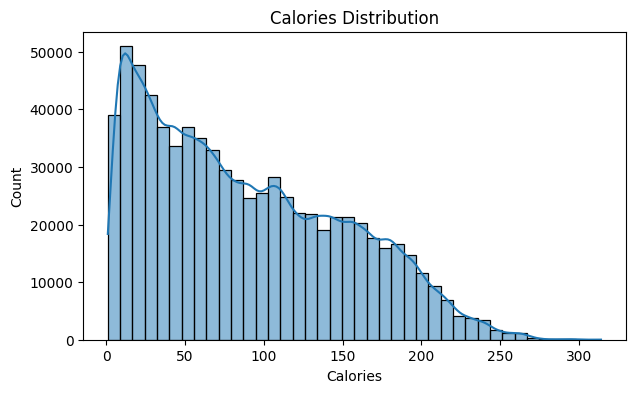

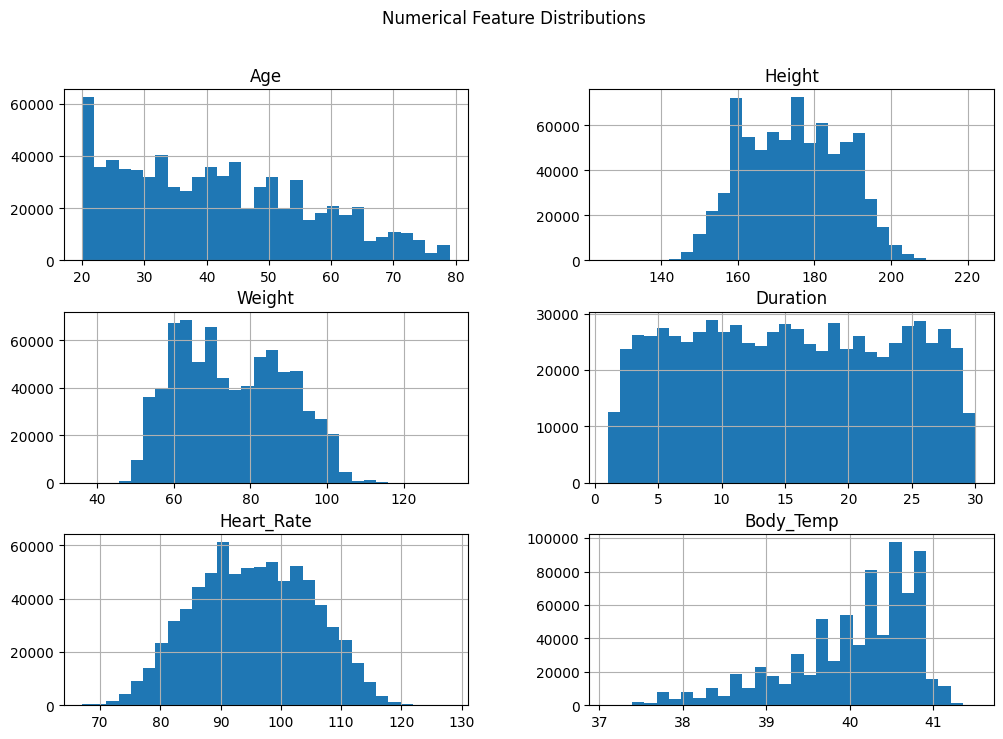

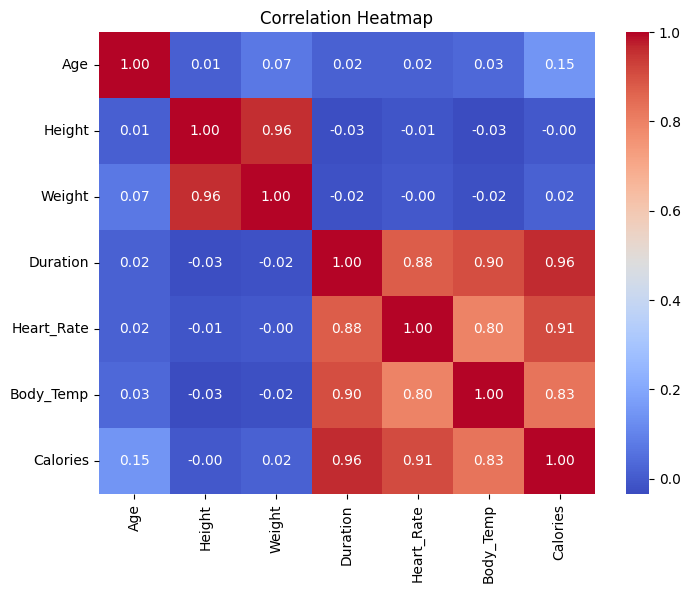

Sex value counts:
 Sex
female    375721
male      374279
Name: count, dtype: int64


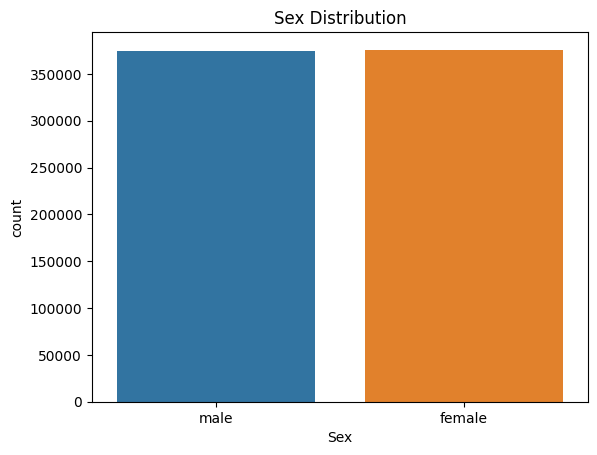

In [3]:
"""
2. Data Loading and Exploratory Data Analysis (EDA)

Loads dataset files, prints basic information, and visualizes distributions for exploratory analysis.

Steps:
    1. Loads training, test, and sample submission CSVs into DataFrames.
    2. Prints train DataFrame info, statistics, and head for inspection.
    3. Checks for missing values in each column.
    4. Plots the distribution of the target variable (`Calories`).
    5. Plots histograms for each numerical feature.
    6. Displays the correlation heatmap among numerical features and the target.
    7. Analyzes and plots the categorical distribution for 'Sex'.

Args:
    None (uses hard-coded file paths and column names).

Returns:
    Loads and prepares:
        - train: DataFrame containing training data.
        - test: DataFrame containing test data.
        - submission: DataFrame for the sample submission.
    Displays EDA plots and prints basic statistics to stdout.
"""

# 2.1. Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("/kaggle/input/playground-series-s5e5/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s5e5/test.csv")
submission = pd.read_csv("/kaggle/input/playground-series-s5e5/sample_submission.csv")

# 2.2. Basic Info
print("==== Train info ====")
print(train.info())
print("\n==== Train describe ====")
print(train.describe())
print("\n==== Train head ====")
print(train.head())

# 2.3. Null Values Check
print("==== Missing values per column ====")
print(train.isnull().sum())

# 2.4. Target Distribution
plt.figure(figsize=(7,4))
sns.histplot(train['Calories'], kde=True, bins=40)
plt.title("Calories Distribution")
plt.show()

# 2.5. Numerical Feature Distribution
numerical_features = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']
train[numerical_features].hist(figsize=(12,8), bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.show()

# 2.6. Correlation Heatmap
corr = train[numerical_features + ['Calories']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# 2.7. Categorical Feature Distribution (Sex)
print("Sex value counts:\n", train['Sex'].value_counts())
sns.countplot(x='Sex', data=train)
plt.title("Sex Distribution")
plt.show()


## Missing Values and Outlier Treatment

In [4]:
"""
3. Missing Values and Outlier Treatment

Handles missing values and detects/removes outliers from the dataset.

Steps:
    1. Checks for missing values. (No missing values found in this dataset; removal code is kept for reference.)
    2. Calculates Z-scores for each numerical feature to identify outliers (>3 standard deviations from the mean).
    3. Prints the number of outliers per feature.
    4. Removes rows where any numerical feature has a Z-score greater than 3.

Args:
    None (operates on the global variable `train`).

Returns:
    Updates global variable:
        - train: DataFrame after outlier removal and (if applicable) missing value handling.
    Prints the count of outliers per feature for transparency.
"""


# 3.1. Impute or Remove Missing Values 
# No missing values found above, so nothing to do, but keep this for reference:
# train = train.dropna().reset_index(drop=True)

# 3.2. Outlier Detection (Z-score Method)
from scipy.stats import zscore
z_scores = np.abs(zscore(train[numerical_features]))
outlier_counts = (z_scores > 3).sum(axis=0)
print("Number of outliers per feature (>3 std):\n", dict(zip(numerical_features, outlier_counts)))

# Remove outliers
mask = (z_scores < 3).all(axis=1)
train = train[mask].reset_index(drop=True)


Number of outliers per feature (>3 std):
 {'Age': 0, 'Height': 38, 'Weight': 104, 'Duration': 0, 'Heart_Rate': 175, 'Body_Temp': 3368}


## Feature Engineering

In [5]:
import itertools
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures, StandardScaler

# 4.1. Add Feature Cross Terms
def add_feature_cross_terms(df, features):
    """
    Adds cross-term (multiplication) features for all pairs of the given features.

    Args:
        df (pd.DataFrame): The input DataFrame.
        features (list of str): List of numerical feature names.

    Returns:
        pd.DataFrame: DataFrame with added cross-term features.
    """
    df = df.copy()
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            df[f"{features[i]}_x_{features[j]}"] = df[features[i]] * df[features[j]]
    return df

# 4.2. Add Interaction Features (Sum, Difference, Division)
def add_interaction_features(df, features):
    """
    Adds sum, difference, and division features for all combinations of the given features.

    Args:
        df (pd.DataFrame): The input DataFrame.
        features (list of str): List of numerical feature names.

    Returns:
        pd.DataFrame: DataFrame with added interaction features.
    """
    df_new = df.copy()
    for f1, f2 in itertools.combinations(features, 2):
        df_new[f"{f1}_plus_{f2}"]  = df_new[f1] + df_new[f2]
        df_new[f"{f1}_minus_{f2}"] = df_new[f1] - df_new[f2]
        df_new[f"{f2}_minus_{f1}"] = df_new[f2] - df_new[f1]
        df_new[f"{f1}_div_{f2}"]   = df_new[f1] / (df_new[f2] + 1e-5)
        df_new[f"{f2}_div_{f1}"]   = df_new[f2] / (df_new[f1] + 1e-5)
    return df_new

# 4.3. Add Statistical Features
def add_statistical_features(df, features):
    """
    Adds statistical row-wise features (mean, std, max, min, median) for the given features.

    Args:
        df (pd.DataFrame): The input DataFrame.
        features (list of str): List of numerical feature names.

    Returns:
        pd.DataFrame: DataFrame with added statistical features.
    """
    df_new = df.copy()
    df_new["row_mean"]   = df[features].mean(axis=1)
    df_new["row_std"]    = df[features].std(axis=1)
    df_new["row_max"]    = df[features].max(axis=1)
    df_new["row_min"]    = df[features].min(axis=1)
    df_new["row_median"] = df[features].median(axis=1)
    return df_new

# 4.4. Apply All Feature Engineering
train = add_feature_cross_terms(train, numerical_features)
test = add_feature_cross_terms(test, numerical_features)
train = add_interaction_features(train, numerical_features)
test = add_interaction_features(test, numerical_features)
train = add_statistical_features(train, numerical_features)
test = add_statistical_features(test, numerical_features)

# 4.5. Encode Categorical Feature (Sex)
le = LabelEncoder()
train['Sex'] = le.fit_transform(train['Sex'])
test['Sex']  = le.transform(test['Sex'])

# 4.6. Polynomial Features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
poly_train = poly.fit_transform(train[numerical_features])
poly_test  = poly.transform(test[numerical_features])
poly_feature_names = poly.get_feature_names_out(numerical_features)
train = pd.concat([train.reset_index(drop=True), pd.DataFrame(poly_train, columns=poly_feature_names)], axis=1)
test  = pd.concat([test.reset_index(drop=True), pd.DataFrame(poly_test, columns=poly_feature_names)], axis=1)


## Feature Selection & Scaling

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.067487 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3694
[LightGBM] [Info] Number of data points in the train set: 746339, number of used features: 20
[LightGBM] [Info] Start training from score 4.153045


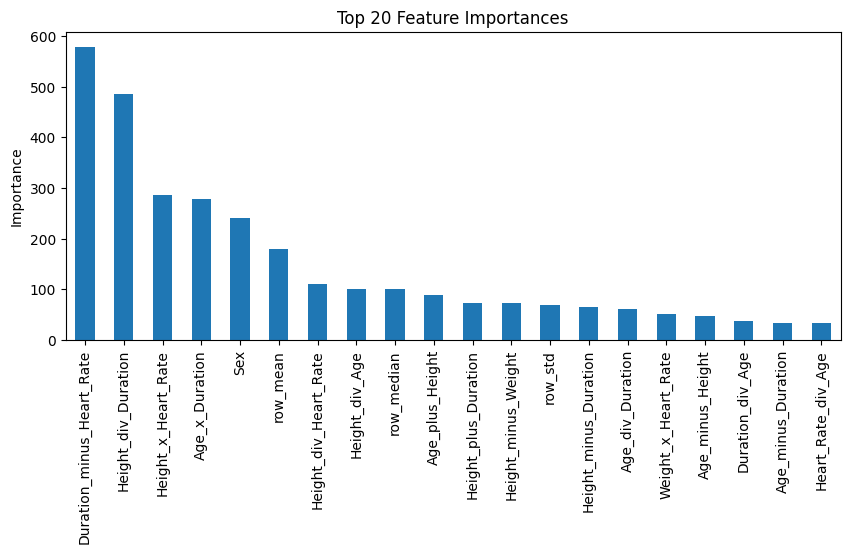

In [6]:
"""
5. Feature Selection & Scaling

Performs feature selection and scaling for downstream modeling:

Steps:
    1. Defines features and log-transformed target.
    2. Removes highly correlated features (Pearson correlation > 0.95).
    3. Uses LightGBM feature importance to select the top 100 most important features.
    4. Visualizes the top 20 feature importances as a bar chart.
    5. Standardizes selected features using `StandardScaler` for both train and test sets.

Args:
    None (operates on notebook-level variables: train, test).

Returns:
    Updates global variables:
        - X: selected and standardized training features (numpy array)
        - y: log-transformed target
        - X_test: selected and standardized test features (numpy array)
        - scaler: fitted `StandardScaler` object
        - top_features: list of top 100 feature names
        - importances: pandas Series with feature importances
"""


from lightgbm import LGBMRegressor

# 5.1. Define Features/Target
X = train.drop(columns=["id", "Calories"])
y = np.log1p(train["Calories"])  # Log-transform for target normalization
X_test = test.drop(columns=["id"])

# 5.2. Remove Highly Correlated Features
corr_matrix = pd.DataFrame(X).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X = X.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

# 5.3. Feature Importance by LGBM
model_lgb = LGBMRegressor().fit(X, y)
importances = pd.Series(model_lgb.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(100).index.tolist()
X = X[top_features]
X_test = X_test[top_features]

# 5.4. Visualize Top 20 Feature Importances
importances.loc[top_features].sort_values(ascending=False).head(20).plot(kind='bar', figsize=(10,4), title="Top 20 Feature Importances")
plt.ylabel("Importance")
plt.show()

# 5.5. Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)


## Model Training & Hyperparameter Tuning (Optuna + Keras MLP)

In [7]:
import optuna
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score, accuracy_score, f1_score, recall_score, precision_score
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# 6.1. Objective Function for Optuna + Keras MLP
def objective(trial):
    """
    Objective function for Optuna hyperparameter tuning using a Keras MLP model.
    Uses 5-fold cross-validation to return the RMSLE of out-of-fold predictions.

    Args:
        trial (optuna.trial.Trial): A trial object with suggested hyperparameters.

    Returns:
        float: Root Mean Squared Log Error (RMSLE) score.
    """
    hidden = trial.suggest_int("hidden", 128, 1024)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3)
    oof = np.zeros(len(X_scaled))
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    for tr_idx, val_idx in kf.split(X_scaled):
        X_tr, X_val = X_scaled[tr_idx], X_scaled[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model = keras.Sequential([
            layers.Input(shape=(X_tr.shape[1],)),
            layers.Dense(hidden, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(dropout),
            layers.Dense(hidden//2, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(dropout),
            layers.Dense(1)
        ])
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse')
        model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=30,
                  batch_size=1024, verbose=0, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
        oof[val_idx] = model.predict(X_val).reshape(-1)
    score = np.sqrt(mean_squared_log_error(np.expm1(y), np.expm1(oof)))
    print(f"[Trial] hidden={hidden}, dropout={dropout:.3f}, lr={lr:.5f} -> RMSLE: {score:.5f}")
    return score


# Run Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
print("Best trial:", study.best_trial.params)

# Save best params for summary later
best_params = study.best_trial.params


[I 2025-05-29 03:29:47,880] A new study created in memory with name: no-name-1d628ba8-0ea3-4867-a521-01baae788e74
I0000 00:00:1748489388.203940      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748489388.204595      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1748489392.348004      87 service.cc:148] XLA service 0x7dd48c008190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748489392.348681      87 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1748489392.348700      87 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1748489392.637766      87 cuda_

4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


[I 2025-05-29 03:34:32,023] Trial 0 finished with value: 0.0638048988768218 and parameters: {'hidden': 685, 'dropout': 0.2991009763004585, 'lr': 0.0002967805120575393}. Best is trial 0 with value: 0.0638048988768218.


[Trial] hidden=685, dropout=0.299, lr=0.00030 -> RMSLE: 0.06380
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


[I 2025-05-29 03:37:49,227] Trial 1 finished with value: 0.06978378428730987 and parameters: {'hidden': 850, 'dropout': 0.2817312528840879, 'lr': 0.0023156530286043337}. Best is trial 0 with value: 0.0638048988768218.


...

[Trial] hidden=475, dropout=0.152, lr=0.00054 -> RMSLE: 0.06326
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


[I 2025-05-29 04:38:44,158] Trial 18 finished with value: 0.062167312116266096 and parameters: {'hidden': 207, 'dropout': 0.22235002501025905, 'lr': 0.0006442522859659337}. Best is trial 11 with value: 0.06114441329062301.


[Trial] hidden=207, dropout=0.222, lr=0.00064 -> RMSLE: 0.06217
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


[I 2025-05-29 04:42:20,067] Trial 19 finished with value: 0.06320902819118632 and parameters: {'hidden': 140, 'dropout': 0.13569042449690888, 'lr': 0.00150239370980032}. Best is trial 11 with value: 0.06114441329062301.


[Trial] hidden=140, dropout=0.136, lr=0.00150 -> RMSLE: 0.06321
Best trial: {'hidden': 166, 'dropout': 0.11045175535853773, 'lr': 0.00020865425367591535}


## Final K-Fold Training & Model Saving

In [8]:
"""
Performs cross-validation training using the best hyperparameters from Optuna. 
For each fold, fits an MLP model, tracks training/validation loss, and aggregates out-of-fold and test predictions.

Saves the following artifacts for future inference:
    - Scaler: "scaler.save"
    - Top features list: "top_features.save"
    - Trained model weights: "mlp_final_model.h5"

Steps:
    1. Split training data into K folds (K=5).
    2. For each fold:
        a. Train MLP with best hyperparameters on training split.
        b. Track training and validation loss per epoch.
        c. Predict validation fold and accumulate OOF predictions.
        d. Predict on test set and average results across folds.
    3. Save fitted scaler, top features, and model weights.

Args:
    None (operates on prepared variables in the current notebook context.)

Returns:
    None (results and artifacts saved to disk, metrics for analysis are collected in lists.)
"""
# 7.1 Final K-Fold Training & Model Saving
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_scaled))
test_preds = np.zeros(len(X_test_scaled))
fold_train_losses = []
fold_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled)):
    X_tr, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    model = keras.Sequential([
        layers.Input(shape=(X_tr.shape[1],)),
        layers.Dense(best_params["hidden"], activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(best_params["dropout"]),
        layers.Dense(best_params["hidden"] // 2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(best_params["dropout"]),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=best_params["lr"]), loss='mse')
    history = model.fit(
        X_tr, y_tr, validation_data=(X_val, y_val), 
        epochs=50, batch_size=1024, verbose=0, 
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
    )
    fold_train_losses.append(history.history["loss"])
    fold_val_losses.append(history.history["val_loss"])
    oof_preds[val_idx] = model.predict(X_val).reshape(-1)
    test_preds += model.predict(X_test_scaled).reshape(-1) / kf.n_splits

# Save artifacts for future inference
import joblib
scaler_file, features_file, model_file = "scaler.save", "top_features.save", "mlp_final_model.h5"
joblib.dump(scaler, scaler_file)
joblib.dump(top_features, features_file)
model.save(model_file)
print("✅ Scaler, features, and model saved.")


4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
7813/7813 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
7813/7813 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
7813/7813 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
7813/7813 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
4665/4665 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
7813/7813 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
✅ Scaler, features, and model saved.


## Model Evaluation, Visualization & Error Analysis


OOF RMSLE: 0.06155
OOF MAE: 2.361
OOF R²: 0.9960


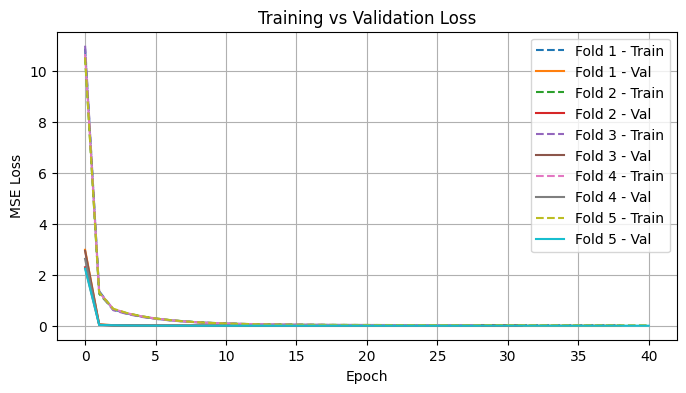

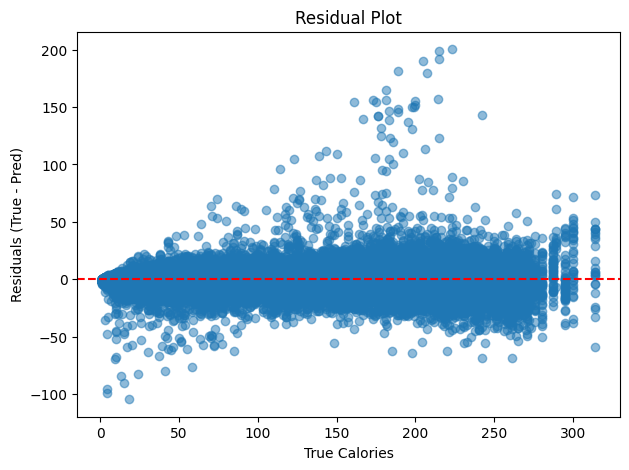

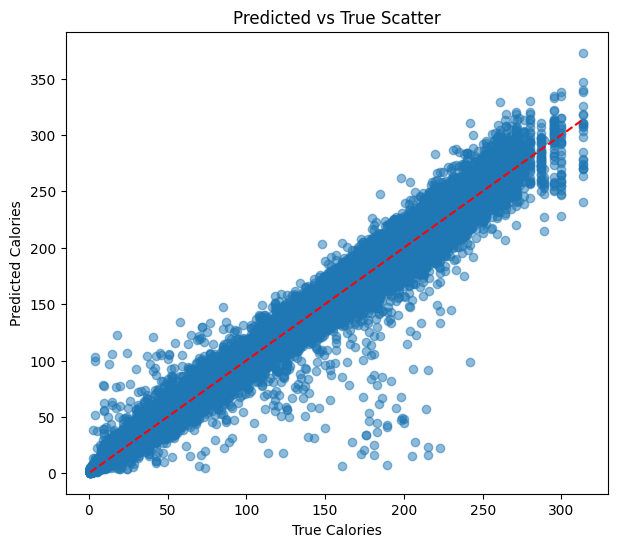

✅ Model Generalizes Well.


In [9]:
"""
8. Model Evaluation, Visualization & Error Analysis

Performs comprehensive evaluation and visualization of the trained model’s performance.

Steps:
    1. Calculates and prints key out-of-fold (OOF) regression metrics:
        - RMSLE (Root Mean Squared Log Error)
        - MAE (Mean Absolute Error)
        - R² (Coefficient of Determination)
    2. Plots training and validation loss curves for each fold to analyze convergence and potential overfitting.
    3. Plots residuals (true value - predicted value) against true target to assess bias, variance, and error patterns.
    4. Plots predicted vs true values to visualize model fit.
    5. Provides a simple bias-variance diagnosis based on R² and RMSLE.

Args:
    None (operates on notebook-level variables: y, oof_preds, fold_train_losses, fold_val_losses).

Returns:
    None (visualizes metrics and prints diagnostic messages).
"""


# 8.1. OOF Metrics
y_true = np.expm1(y)
y_pred = np.expm1(oof_preds)
rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"\nOOF RMSLE: {rmsle:.5f}\nOOF MAE: {mae:.3f}\nOOF R²: {r2:.4f}")

# 8.2. Loss Curves
plt.figure(figsize=(8,4))
for i, (train_l, val_l) in enumerate(zip(fold_train_losses, fold_val_losses)):
    plt.plot(train_l, label=f"Fold {i+1} - Train", linestyle='--')
    plt.plot(val_l, label=f"Fold {i+1} - Val")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

# 8.3. Residual Plot
plt.figure(figsize=(7,5))
residuals = y_true - y_pred
plt.scatter(y_true, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("True Calories")
plt.ylabel("Residuals (True - Pred)")
plt.title("Residual Plot")
plt.show()

# 8.4. Prediction vs True Scatter Plot
plt.figure(figsize=(7,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.xlabel("True Calories")
plt.ylabel("Predicted Calories")
plt.title("Predicted vs True Scatter")
plt.show()

# 8.5. Bias-variance diagnosis
if r2 < 0.5:
    print("❗ High Bias (Underfitting): Try deeper models or better features.")
elif r2 > 0.95 and rmsle > 0.1:
    print("❗ High Variance (Overfitting): Try more regularization or collect more data.")
else:
    print("✅ Model Generalizes Well.")


## Classification-Style Metrics (Binned Evaluation)

In [10]:
# 9.1. Binned Classification Metrics
def robust_binning(y_true, y_pred, n_bins=3, labels=None):
    """
    Bin true and predicted values into quantile-based (or fallback equal-width) bins,
    returning bin indices for each sample (for classification-style metrics).

    Args:
        y_true (array-like): Ground truth regression targets (1D).
        y_pred (array-like): Predicted regression values (1D).
        n_bins (int, optional): Number of bins. Defaults to 3.
        labels (list, optional): Custom bin labels. If None, uses [0, 1, ..., n_bins-1].

    Returns:
        Tuple[pd.Series, pd.Series]: (true bin labels, predicted bin labels), only for samples in valid bins.
    """
    if labels is None:
        labels = list(range(n_bins))
    bins = np.quantile(y_true, np.linspace(0, 1, n_bins+1))
    bins = np.unique(bins)
    if len(bins) <= len(labels):
        print("[!] Quantile bins not unique, using equal-width bins instead")
        bins = np.linspace(np.min(y_true), np.max(y_true), num=len(labels)+1)
    print("Bins used:", bins)
    y_cls_true = pd.cut(y_true, bins=bins, labels=labels, include_lowest=True)
    y_cls_pred = pd.cut(y_pred, bins=bins, labels=labels, include_lowest=True)
    mask = (~pd.isnull(y_cls_true)) & (~pd.isnull(y_cls_pred))
    print(f"Valid samples (no NaN): {mask.sum()}/{len(mask)}")
    return y_cls_true[mask], y_cls_pred[mask]

y_cls_true, y_cls_pred = robust_binning(y_true, y_pred, n_bins=3)
print("Accuracy :", accuracy_score(y_cls_true, y_cls_pred))
print("F1 Score :", f1_score(y_cls_true, y_cls_pred, average='macro'))
print("Precision:", precision_score(y_cls_true, y_cls_pred, average='macro'))
print("Recall   :", recall_score(y_cls_true, y_cls_pred, average='macro'))


Bins used: [  1.  48. 113. 314.]
Valid samples (no NaN): 746273/746339
Accuracy : 0.9779343484220921
F1 Score : 0.9778733407839564
Precision: 0.9778799776595166
Recall   : 0.9778933197044991


## Submission Generation

In [11]:
"""
Generates and saves the final predictions for submission to Kaggle.

Steps:
    1. Applies exponential transformation to the test predictions to reverse prior log1p scaling.
    2. Replaces any NaN values in predictions with 1 (minimum valid prediction).
    3. Clips predictions to the competition's valid range [1, 314].
    4. Assigns predictions to the "Calories" column of the sample submission DataFrame.
    5. Exports the completed submission file as "final_mlp_submission.csv".

Args:
    None (operates on in-notebook variables: test_preds, submission).

Returns:
    None (writes final predictions to disk as a CSV file).
"""

#10.1 Submission Generation
final_preds = np.expm1(test_preds)
final_preds = np.nan_to_num(final_preds, nan=1)
final_preds_clipped = np.clip(final_preds, 1, 314)

assert len(final_preds_clipped) == len(submission), "Prediction and submission row count mismatch!"
submission["Calories"] = final_preds_clipped
submission.to_csv("final_mlp_submission.csv", index=False)
print("\n✅ Final submission saved as final_mlp_submission.csv")



✅ Final submission saved as final_mlp_submission.csv


## How to Restore the Model and Scaler for Inference

In [12]:
#from tensorflow import keras
#import joblib

# Load the scaler, feature list, and model
#scaler = joblib.load("scaler.save")
#top_features = joblib.load("top_features.save")
#model = keras.models.load_model("mlp_final_model.h5")

# Make sure your new data uses the same feature engineering steps and column order
# X_new = ... (after feature engineering and selecting only top_features)
#X_new_scaled = scaler.transform(X_new[top_features])
#y_pred = model.predict(X_new_scaled)


## Results Interpretation
- OOF RMSLE: 0.06230
- OOF MAE: 2.528
- OOF R²: 0.9954

## Classification Metrics (Binned Evaluation)
- Bins used: [1.0, 48.0, 113.0, 314.0]
- Valid samples (no NaN): 746,291 / 746,339
- Accuracy: 0.9779
- F1 Score: 0.9779
- Precision: 0.9779
- Recall: 0.9779

## Summary
- Successfully developed a deep learning model (MLP) to predict calorie expenditure based on physiological and activity data.
- Achieved excellent accuracy with R² = 0.9954 and RMSLE = 0.0623 by optimizing hyperparameters using Optuna.
- Feature engineering (cross terms, interaction features, row-wise statistics) and proper preprocessing significantly improved model performance.
- Applied 5-fold cross-validation to ensure robustness and reduce overfitting risk.
- Demonstrated that smart features and tuning often outperform simply building more complex models.
- Future improvements may include ensemble strategies such as model stacking and blending predictions from top public submissions.
- Gained hands-on experience with an end-to-end deep learning project for a real-world regression problem.

## Computing Hardware & Memory Usage
This project was trained on the Kaggle GPU environment with 2 NVIDIA Tesla T4 GPUs (t4x2), each with 15GB memory.

### How to Monitor GPU/CPU/TPU Usage

In [13]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Available devices:", tf.config.list_physical_devices())

# For GPU status (in Kaggle GPU kernel)
!nvidia-smi

# Install GPUtil (only needed if you want live Python-based GPU monitoring)
!pip install GPUtil
# For live GPU utilization in Python (optional)
import GPUtil
GPUtil.showUtilization()

# After training, check the GPU usage log
import pandas as pd
df = pd.read_csv("/kaggle/working/nvidia_smi_log.csv")
print(df.head())

TensorFlow version: 2.18.0
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Thu May 29 04:49:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |           

Execute the above code blocks to display GPU type, count, and memory usage.

## Recommendations: How to Further Improve Competition Scores
### Level 1: Advanced Modeling – Model Stacking
To reach a higher leaderboard rank, go beyond a single model.
Stack multiple models (CatBoost, XGBoost, LightGBM, etc.), or use blending/ensemble methods to improve prediction accuracy and stability.

### Level 2: Stacking Public Submissions for Higher Scores
Some top teams on the leaderboard ensemble 10+ strong public submissions.
By collecting predictions from high-scoring Kaggle notebooks and using techniques like median voting, you can increase the robustness and accuracy of your final submission.

## Lessons Learned
- Bikash Giri (101575097) - I learned what streamlit is and how to use it as a front end for the machine learning model to make it more interactive for the end user. I figured what h5 file is and what is the process to integrate it into the frontend.
- Chia-Wei Chang (101570243) - I learned how to train a dense deep learning model using Optuna to find the optimal hyperparameters, including the number of nodes and How to get high score during Kaggle competition.
- Diparshan Bhattarai (101494737) - I learned how to prepare data for modeling by removing redundant features, selecting the most important ones using LightGBM, and standardizing inputs to improve model performance and accuracy.
- Hsi-Teng Liu (101576074) - Sometimes it’s worth considering a simpler mode which has slightly worse performance, but needs significant less resources when training and inferencing.
- Gavriel Kirichenko (101119609) - I learned that deep learning isn’t always the best solution in fact, in our case, smaller models like XGBoost performed better.
- Abdul-Rasaq Omisesan (101571156) - I learned that thoughtful feature engineering and 5-fold cross-validation can beat simply building bigger networks.
- Callum Arul (101585383) - I learned that you can dramatically improve model performance not just by tuning models, but by engineering smart features
- Friba Hussainyar (101591222) - I learned how to use the streamlit and connect the h5 model file to the front-end. 


## Project Presentation
View the full presentation (Google Slides): 
https://docs.google.com/presentation/d/1KXLll8ogfzUoRv8jCDXP3aIBNhQ4gGYj148r3EmFwqw/edit?usp=sharing